In [23]:
import torch
import numpy as np
import matplotlib.pyplot as plt

mse_tensor = torch.load("mse_ct.pt")
rmse_tensor = torch.load("rmse_ct.pt")
diameters_tensor = torch.load("diameters.pt")
print('MSE shape',mse_tensor.shape)
print('RMSE shape',rmse_tensor.shape)
print('Diameters shape',diameters_tensor.shape)

def visualize_metrics(rmse_tensor, diameters, metric):    
    rmse_values = rmse_tensor.flatten()
    #x = np.arange(len(mse_values))
    x = diameters.flatten()
    mse_values_np = rmse_values.numpy()

    #threshold = thresh
    threshold = 1.5*diameters

    x_below = x[rmse_values <= threshold]
    y_below = rmse_values[rmse_values <= threshold]

    x_above = x[rmse_values > threshold]
    y_above = rmse_values[rmse_values > threshold]

    # Plot both groups with labels
    plt.scatter(x_below, y_below, c='green', edgecolor='g', label='inside GT')
    plt.scatter(x_above, y_above, c='blue', edgecolor='k', label='outside GT')

    #colors = ['blue' if val > 50 else 'green' for val in mse_values_np]
    #edgecolors = ['k' if val > 50 else 'g' for val in mse_values_np]
    #labels = ['outside GT' if val > 50 else 'inside GT' for val in mse_values_np]

    #plt.scatter(x, mse_values_np, c=colors, edgecolor=edgecolors, label=labels)
    plt.xlabel('Lung nodule Diameter')
    plt.ylabel(f'{metric} value of each lung nodule center')
    #plt.title('MSE Values with Threshold Highlight')
    plt.legend()
    plt.grid(True)
    plt.show()

MSE shape torch.Size([67, 1])
RMSE shape torch.Size([67])
Diameters shape torch.Size([67])


In [17]:
#visualize_metrics(mse_tensor, metric='MSE')

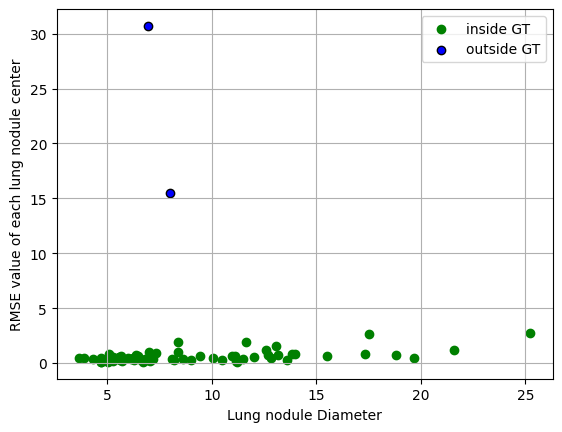

In [24]:
visualize_metrics(rmse_tensor, diameters_tensor, metric='RMSE')